CUSTOMER CHURN PREDICTION USING DECISION TREE CLASSIFICATION

1. DATASET OVERVIEW
--------------------------------------------------
Dataset Shape: (10000, 13)

First 5 Records:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Missing Values:
CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
Num Of Products     0
Has Credit Card     0
Is Active Member    0
Estimated Salary    0
Churn               0
dtype: int64

Data Types:
CustomerId            int64
Surname              object
CreditScore           int64
Geography            object
Gender               object
Age                   int64
Tenure                int64
Balance             float64
Num Of Products       int64
Has Credit Card       int64
Is Active Member      int64
Estimated Salary    float64
Churn                 int64
dtype: object

2. DATA PREPROCESSING
--------------------------------------------------
Removed Columns: ['CustomerId', 'Surname']
Updated Dataset Shape: (10000, 11)

Target Variable: Churn
0 = Customer Retained
1 = Customer Churned

Target Distribution:
Churn
0    7963
1    2037
Name: count, dtype: int64


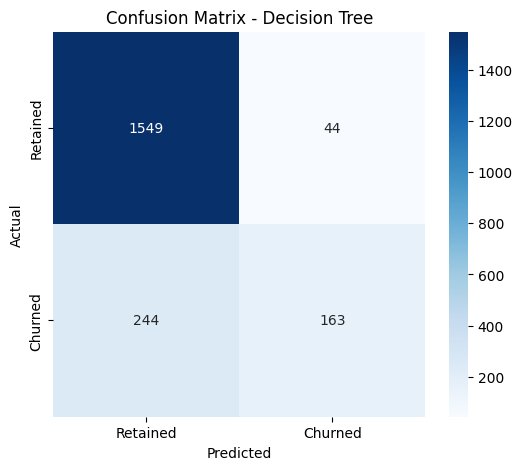


8. DECISION TREE VISUALIZATION
--------------------------------------------------


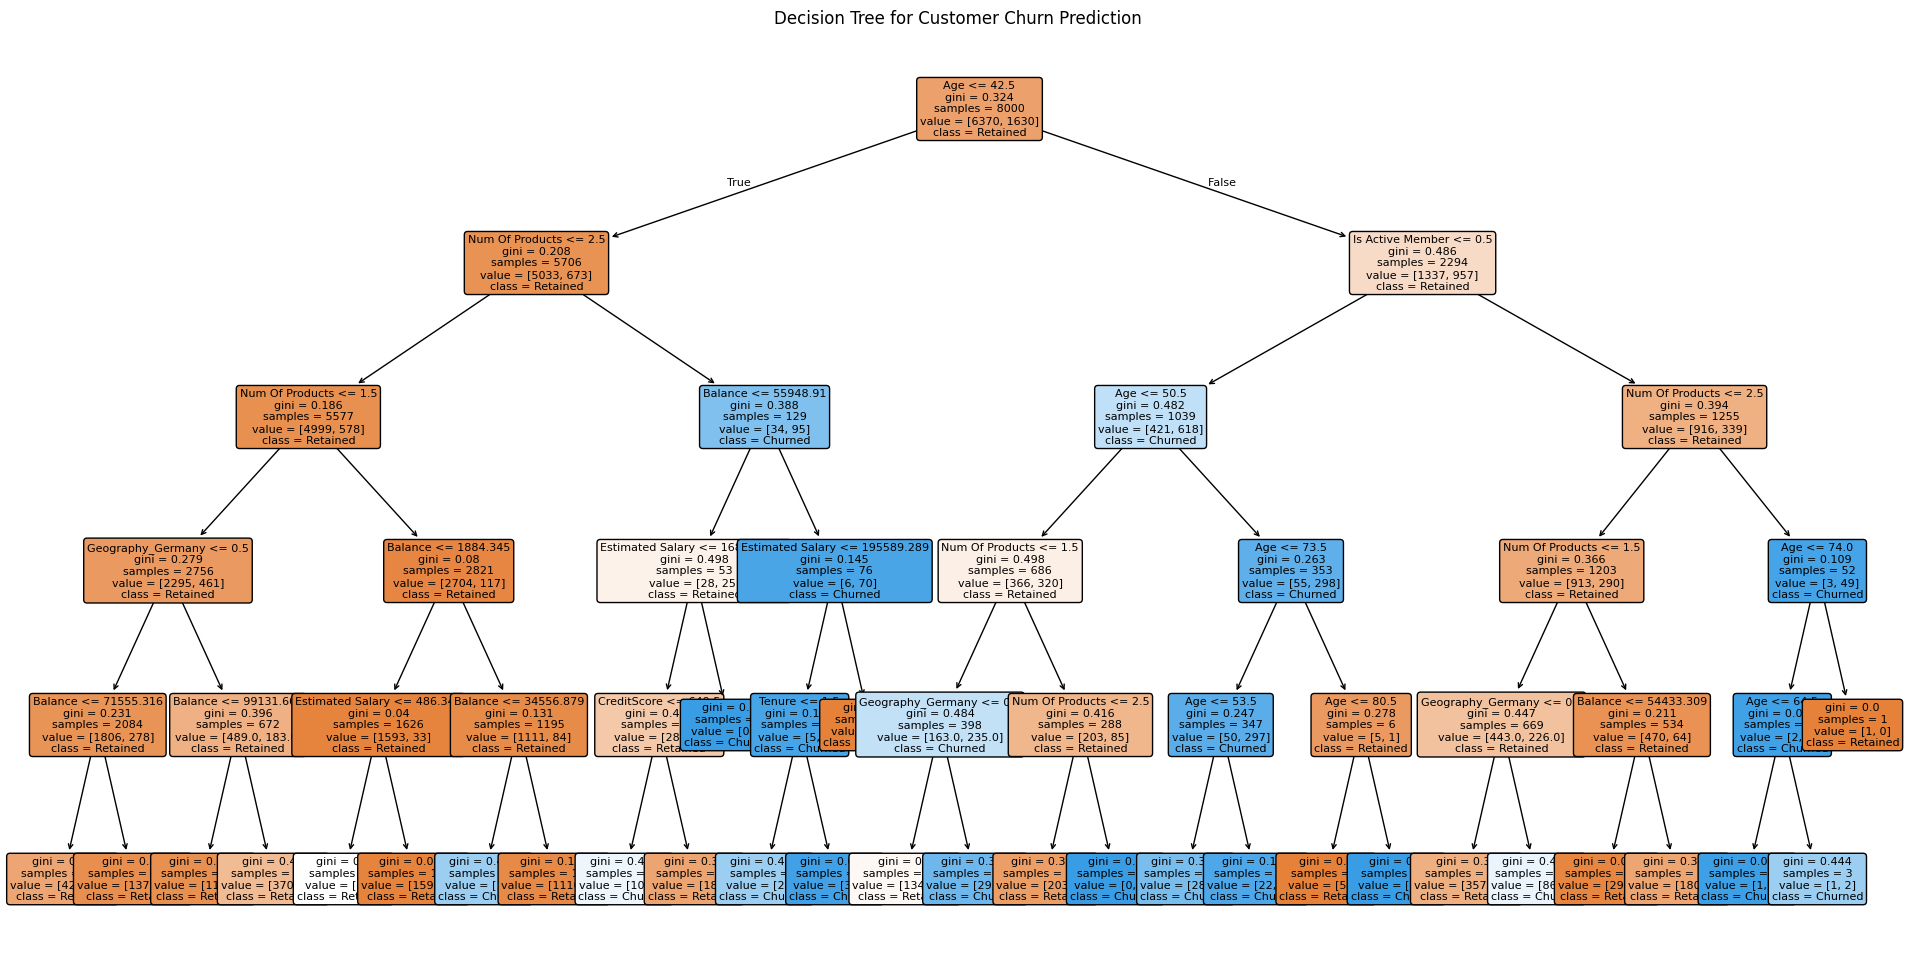


9. FEATURE IMPORTANCE
--------------------------------------------------


,Feature,Importance
1,Age,0.411949
4,Num Of Products,0.327647
6,Is Active Member,0.132522
8,Geography_Germany,0.060367
3,Balance,0.054598
7,Estimated Salary,0.009612
0,CreditScore,0.002279
2,Tenure,0.001026
5,Has Credit Card,0.000000
9,Geography_Spain,0.000000


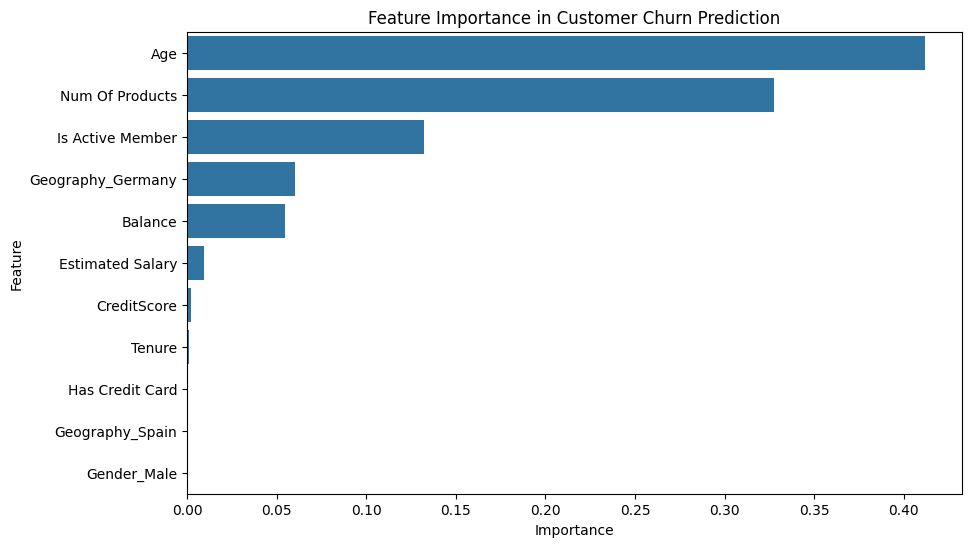


10. ACTUAL VS PREDICTED VALUES
--------------------------------------------------


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


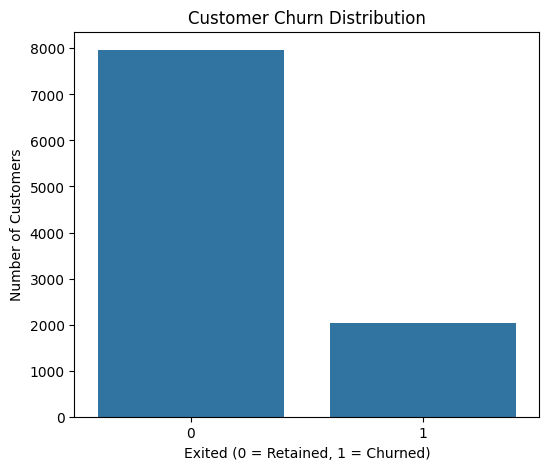


KEY FINDINGS

Top 5 Important Features:
- Age: 0.4119
- Num Of Products: 0.3276
- Is Active Member: 0.1325
- Geography_Germany: 0.0604
- Balance: 0.0546

Model Performance:
- Accuracy  : 85.60%
- Precision : 78.74%
- Recall    : 40.05%
- F1-Score  : 53.09%


In [9]:
# Prayas Sharma
# CU24250180
# Sec - 'B'

# ============================================================
# EXPERIMENT NO. 8
# Customer Churn Prediction using Decision Tree Classification
# ============================================================

# -----------------------------
# 1. Import Required Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("CUSTOMER CHURN PREDICTION USING DECISION TREE CLASSIFICATION")
print("=" * 70)
df = pd.read_csv("/content/Bank Churn Modelling.csv")
df.head()


# -----------------------------
# 2. Dataset Overview
# -----------------------------
print("\n1. DATASET OVERVIEW")
print("-" * 50)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


# -----------------------------
# 3. Remove Unnecessary Columns
# -----------------------------
print("\n2. DATA PREPROCESSING")
print("-" * 50)

# Remove identifier columns if they exist
columns_to_remove = ['RowNumber', 'CustomerId', 'Surname']

existing_columns = [col for col in columns_to_remove if col in df.columns]

if existing_columns:
    df = df.drop(existing_columns, axis=1)

print("Removed Columns:", existing_columns)
print("Updated Dataset Shape:", df.shape)


# -----------------------------
# 4. Separate Features and Target
# -----------------------------
X = df.drop('Churn', axis=1)
y = df['Churn']

print("\nTarget Variable: Churn")
print("0 = Customer Retained")
print("1 = Customer Churned")

print("\nTarget Distribution:")
print(y.value_counts())


# -----------------------------
# 5. Encode Categorical Variables
# -----------------------------
# Encode Geography and Gender
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

print("\nFeatures after encoding:")
print(X.columns.tolist())

print("\nEncoded Feature Shape:", X.shape)


# -----------------------------
# 6. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n3. TRAIN-TEST SPLIT")
print("-" * 50)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# -----------------------------
# 7. Build Decision Tree Model
# -----------------------------
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("\n4. DECISION TREE MODEL")
print("-" * 50)
print("Criterion : Gini Index")
print("Maximum Depth:", 5)
print("Model training completed successfully.")


# -----------------------------
# 8. Make Predictions
# -----------------------------
y_pred = model.predict(X_test)

print("\n5. PREDICTIONS")
print("-" * 50)
print("Predictions completed successfully.")
print("\nFirst 20 Predictions:")
print(y_pred[:20])


# -----------------------------
# 9. Model Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n6. MODEL EVALUATION")
print("-" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Retained', 'Churned']
))


# -----------------------------
# 10. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\n7. CONFUSION MATRIX")
print("-" * 50)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


# -----------------------------
# 11. Decision Tree Visualization
# -----------------------------
print("\n8. DECISION TREE VISUALIZATION")
print("-" * 50)

plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Retained', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Customer Churn Prediction")
plt.show()


# -----------------------------
# 12. Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n9. FEATURE IMPORTANCE")
print("-" * 50)
display(importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance in Customer Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# -----------------------------
# 13. Actual vs Predicted
# -----------------------------
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\n10. ACTUAL VS PREDICTED VALUES")
print("-" * 50)
display(comparison.head(20))


# -----------------------------
# 14. Churn Distribution
# -----------------------------
plt.figure(figsize=(6, 5))

sns.countplot(
    x=df['Churn']
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()


# -----------------------------
# 15. Key Findings
# -----------------------------
print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

top_features = importance.head(5)

print("\nTop 5 Important Features:")
for i, row in top_features.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

print("\nModel Performance:")
print(f"- Accuracy  : {accuracy:.2%}")
print(f"- Precision : {precision:.2%}")
print(f"- Recall    : {recall:.2%}")
print(f"- F1-Score  : {f1:.2%}")


## Business Recommendations

1. Identify customers who have a high probability of churning and provide targeted retention offers.

2. Pay attention to the most influential features identified by the Decision Tree model.

3. Improve customer engagement through personalized banking services and loyalty programs.

4. Provide better customer support to customers who show signs of dissatisfaction.

5. Use churn predictions to prioritize retention campaigns and reduce potential revenue loss.

6. Regularly monitor high-risk customers and provide suitable services or incentives to encourage them to remain with the bank.

# Conclusion

A Decision Tree Classification model was developed to predict customer churn using the Bank Customer Churn dataset.

The dataset was preprocessed, categorical variables were encoded, and the data was divided into training and testing sets. A Decision Tree classifier was trained using the Gini Index.

The model was evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. The Decision Tree was also visualized to understand its decision-making process, and feature importance was analyzed to identify the factors that contributed most to churn prediction.

The insights obtained from the model can help organizations identify customers who are more likely to churn and develop targeted strategies to improve customer retention and reduce potential revenue loss.

# Questions and Answers

### Q1. What is classification, and how does it differ from regression?

Classification is a supervised machine learning technique used to predict discrete categories or classes. For example, predicting whether a bank customer will churn or remain with the bank.

Regression predicts continuous numerical values such as salary, house price, or revenue. Therefore, classification predicts categories, whereas regression predicts numerical values.

### Q2. Explain the working principle of the Decision Tree algorithm.

A Decision Tree works by repeatedly splitting the dataset into smaller groups based on feature values. At each node, the algorithm selects a feature and split that provides the best separation of the target classes. The process continues until a stopping condition is reached. The final leaf nodes represent the predicted classes.

### Q3. Differentiate between Gini Index and Entropy as splitting criteria.

Gini Index and Entropy are measures of impurity used to select the best split in a Decision Tree.

**Gini Index:** Measures the probability of incorrectly classifying a randomly selected data point.

**Entropy:** Measures the amount of uncertainty or disorder in the data.

A lower impurity indicates a better split. Gini is commonly used because it is computationally simpler, while Entropy is based on information gain.

### Q4. What is a Confusion Matrix? Explain its components.

A Confusion Matrix is a table used to evaluate the performance of a classification model.

- **True Positive (TP):** Customer actually churned and the model predicted churn.
- **True Negative (TN):** Customer did not churn and the model predicted no churn.
- **False Positive (FP):** Customer did not churn but the model predicted churn.
- **False Negative (FN):** Customer churned but the model predicted no churn.

### Q5. Define Accuracy, Precision, Recall, and F1-Score. Why are these metrics important?

**Accuracy:** The proportion of total predictions that are correct.

**Precision:** The proportion of predicted positive cases that are actually positive.

**Recall:** The proportion of actual positive cases that are correctly identified.

**F1-Score:** The harmonic mean of Precision and Recall.

These metrics are important because accuracy alone may not provide enough information when the dataset contains imbalanced classes. Precision, Recall and F1-Score provide a better understanding of classification performance.

### Q6. What is overfitting in a Decision Tree? How can it be reduced?

Overfitting occurs when a Decision Tree becomes too complex and learns the training data, including noise, instead of learning general patterns.

Overfitting can be reduced by limiting the maximum tree depth, increasing the minimum number of samples required for splitting, pruning the tree, and using cross-validation.

### Q7. Why is customer churn prediction important for businesses?

Customer churn prediction helps businesses identify customers who are likely to leave. Organizations can then take early action through personalized offers, better customer service, and retention campaigns. This can help reduce customer loss and protect revenue.

### Q8. What are the advantages and limitations of the Decision Tree algorithm?

**Advantages:**

- Easy to understand and interpret.
- Requires relatively little data preprocessing.
- Can handle different types of features after suitable encoding.
- Provides useful feature importance information.
- Decision rules can be visualized.

**Limitations:**

- Can overfit the training data.
- Small changes in data can produce a different tree.
- Very deep trees can become difficult to interpret.
- Its performance can sometimes be lower than ensemble methods such as Random Forest.

### Q9. Mention three real-world applications of Decision Tree Classification other than customer churn prediction.

1. Loan approval and credit risk classification.
2. Medical disease or diagnosis classification.
3. Spam email detection.

Other applications include fraud detection and employee attrition prediction.

### Q10. How can the insights obtained from a churn prediction model help organizations improve customer retention and business profitability?

A churn prediction model identifies customers who have a higher risk of leaving. Organizations can use these insights to create targeted retention campaigns, improve customer service, offer personalized plans or incentives, and address common reasons for customer dissatisfaction.

By focusing resources on customers with higher churn risk, organizations can reduce customer loss, retain recurring revenue, and improve overall business profitability.